In [26]:
# CNN : 개/고양이 이미지(고해상도) 분류 - 이진분류
# pip install tensorflow_datasets

In [27]:
import os, shutil  # 파일 / 폴더를 이동, 복사, 삭제할때 사용 ex) shutil.copy('a.txt','b.txt')
import tensorflow_datasets as tfds
print(tfds.list_builders())

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(1)
tf.random.set_seed(1)

['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset', 'ai2_arc', 'ai2_arc_with_ir', 'ai2dcaption', 'aloha_mobile', 'amazon_us_reviews', 'anli', 'answer_equivalence', 'arc', 'asimov_dilemmas_auto_val', 'asimov_dilemmas_scifi_train', 'asimov_dilemmas_scifi_val', 'asimov_injury_val', 'asimov_multimodal_auto_val', 'asimov_multimodal_manual_val', 'asqa', 'asset', 'assin2', 'asu_table_top_converted_externally_to_rlds', 'austin_buds_dataset_converted_externally_to_rlds', 'austin_sailor_dataset_converted_externally_to_rlds', 'austin_sirius_dataset_converted_externally_to_rlds', 'bair_robot_pushing_small', 'bc_z', 'bccd', 'beans', 'bee_dataset', 'beir', 'berkeley_autolab_ur5', 'berkeley_cable_routing', 'berkeley_fanuc_manipulation', 'berkeley_gnm_cory_hall', 'berkeley_gnm_recon', 'berkeley_gnm_sac_son', 'berkeley_mvp_converted_externally_to_rlds', 'berkeley_rpt_converted_externally_to_rlds', 'big_patent', 'bigearthnet', 'billsum', 'binarized_mnist', 'binary_alpha_digits', 'b

In [28]:
# data load
(dataset, info) = tfds.load('cats_vs_dogs', with_info = True, as_supervised = True)
print(dataset)
print(info)

{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citat

['cat', 'dog']
dict_keys(['train'])
(409, 336, 3) <dtype: 'int64'>
1


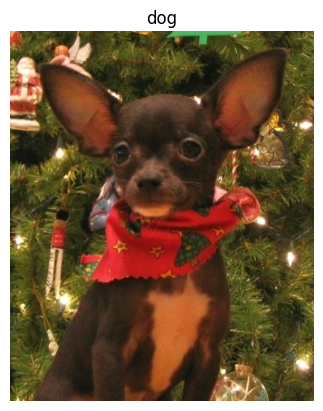

In [29]:
label_names = info.features['label'].names
print(label_names) # ['cat', 'dog']
print(dataset.keys()) # dict_keys([Split('train')])

for image, label in dataset['train'].skip(1).take(1):
    print(image.shape, label.dtype)
    print(label.numpy())
    plt.imshow(image)
    plt.title(label_names[label.numpy()])
    plt.axis('off')
    plt.show()

In [30]:
from tensorflow.python.distribute.parameter_server_strategy_v2 import ps_values
# 폴더 구조 생성
base_dir = './cats_and_dogs_filtered'  # 이미지 루트 폴더
train_dir = os.path.join(base_dir, 'train') # 학습 폴더
validation_dir = os.path.join(base_dir, 'validation') # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

for d in [train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir]:
    os.makedirs(d, exist_ok = True)

# train / validation 분할 + 이미지 저장
IMG_SIZE = (150, 150)

def save_imageFunc(img, label, idx, split):
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.cast(img, tf.uint8).numpy()

  if split == 'train':
    folder = train_cats_dir if label == 0 else train_dogs_dir
  else:
    folder = val_cats_dir if label == 0 else val_dogs_dir

  path = os.path.join(folder, f"{idx}.jpg")
  tf.keras.preprocessing.image.save_img(path, img) # 이미지가 해당 경로에 저장

total = info.splits['train'].num_examples
print(total)   # 23262

train_size = int(total * 0.8)
print(train_size) # 18609

for i, (img, label) in enumerate(dataset['train']):
  if i < train_size:
    save_imageFunc(img, label, i, 'train')
  else:
    save_imageFunc(img, label, i, 'val')

print('데이터 준비 완료')

23262
18609
데이터 준비 완료


In [31]:
PATH = './cats_and_dogs_filtered'  # 이미지 루트 폴더
train_dir = os.path.join(PATH, 'train') # 학습 폴더
validation_dir = os.path.join(PATH, 'validation') # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

# 경로 유무 확인 및 출력
for p in [train_dir, train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir, validation_dir]:
    print(f"{p} -> {os.path.exists(p)}")


print('cats(train) : ', len(os.listdir(train_cats_dir)), ' | dogs(train) : ', len(os.listdir(train_dogs_dir)))
print('cats(val) : ', len(os.listdir(val_cats_dir)), ' | dogs(val) : ', len(os.listdir(val_dogs_dir)))

./cats_and_dogs_filtered/train -> True
./cats_and_dogs_filtered/train/cats -> True
./cats_and_dogs_filtered/train/dogs -> True
./cats_and_dogs_filtered/validation/cats -> True
./cats_and_dogs_filtered/validation/dogs -> True
./cats_and_dogs_filtered/validation -> True
cats(train) :  9381  | dogs(train) :  9228
cats(val) :  2277  | dogs(val) :  2376


In [32]:
 # 참고 : Colab 폴더 전체를 내 PC로 다운로드
import shutil
from google.colab import files

# 폴더를 zip 파일로 압축
shutil.make_archive('cats_and_dogs_filtered', # 생성될 zip파일 이름
                    'zip', # 압축 형식
                    './cats_and_dogs_filtered' # 압축할 폴더명
)
files.download('cats_and_dogs_filtered.zip')  # 내 PC로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from numpy.random import shuffle
# 이미지 증강 / 스케일링
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 128
EPOCHS = 20  # 실제는 더 큰 수 사용

train_datagen = ImageDataGenerator(
    rescale = 1./255,   # [0., 1]  스케일(이미지 픽셀값을 0 ~ 1 사이로 조정)
    rotation_range = 15,  # 회전
    width_shift_range = 0.1,  # 좌우 이동
    height_shift_range = 0.1,  # 상하 이동
    horizontal_flip = True,  # 좌우 반전
)
val_datagen = ImageDataGenerator(rescale = 1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle = True
)
val_data = val_datagen.flow_from_directory(
    validation_dir,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle = False
)

print(train_data.class_indices)
print(train_data.classes)
print(val_data.class_indices)
print(val_data.classes)

Found 18609 images belonging to 2 classes.
Found 4653 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}
[0 0 0 ... 1 1 1]
{'cats': 0, 'dogs': 1}
[0 0 0 ... 1 1 1]


{0: 'cats', 1: 'dogs'}


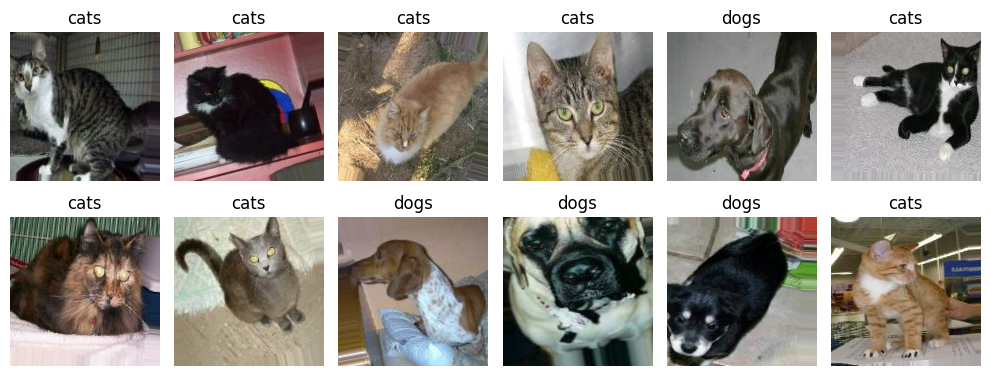

In [38]:
# 로드된 이미지 미리보기 (한 배치)
imgs, labels = next(train_data)
n_show = min(12, imgs.shape[0])
cols = 6
rows = int(np.ceil(n_show / cols)) # 행 갯수

idx_to_name = {v:k for k, v in train_data.class_indices.items()}
print(idx_to_name) # {0: 'cats', 1: 'dogs'}

plt.figure(figsize = (10, 2 * rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(imgs[i])
  ax.set_title(idx_to_name[labels[i]])
  ax.axis('off')
plt.tight_layout()
plt.show()


In [40]:
# model 생성
model = Sequential([
    Input((IMG_HEIGHT, IMG_WIDTH, 3)),

    Conv2D(16, 3, activation = 'relu'),
    MaxPooling2D(),  # featuremap의 절반크기로 다운 샘플링 됨

    Conv2D(32, 3, padding='same', activation = 'relu'),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation = 'relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(512, activation = 'relu'),
    Dropout(0.3),
    Dense(1, activation = 'sigmoid')
])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 74, 74, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

os.makedirs('chackpoints', exist_ok = True)
ckpt = ModelCheckpoint(
    filepath = 'chkpoints/catdog_best.keras',
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True,
    verbose=1
)
es = EarlyStopping(
    monitor = 'val_accuracy',
    patience = 5,
    restore_best_weights = True,
)

history = model.fit(
    train_data,
    epochs = EPOCHS,
    validation_data = val_data,
    callbacks = [ckpt, es],
    verbose = 2
)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.66108, saving model to chkpoints/catdog_best.keras

Epoch 1: finished saving model to chkpoints/catdog_best.keras
146/146 - 559s - 4s/step - accuracy: 0.5934 - loss: 0.6957 - val_accuracy: 0.6611 - val_loss: 0.6128
Epoch 2/20

Epoch 2: val_accuracy improved from 0.66108 to 0.73845, saving model to chkpoints/catdog_best.keras

Epoch 2: finished saving model to chkpoints/catdog_best.keras
146/146 - 573s - 4s/step - accuracy: 0.6932 - loss: 0.5826 - val_accuracy: 0.7384 - val_loss: 0.5242
Epoch 3/20

Epoch 3: val_accuracy improved from 0.73845 to 0.77735, saving model to chkpoints/catdog_best.keras

Epoch 3: finished saving model to chkpoints/catdog_best.keras
146/146 - 677s - 5s/step - accuracy: 0.7293 - loss: 0.5372 - val_accuracy: 0.7773 - val_loss: 0.4739
Epoch 4/20

Epoch 4: val_accuracy improved from 0.77735 to 0.79024, saving model to chkpoints/catdog_best.keras

Epoch 4: finished saving model to chkpoints/catdog_best.keras


val_acc : 0.8786, val_loss : 0.2896


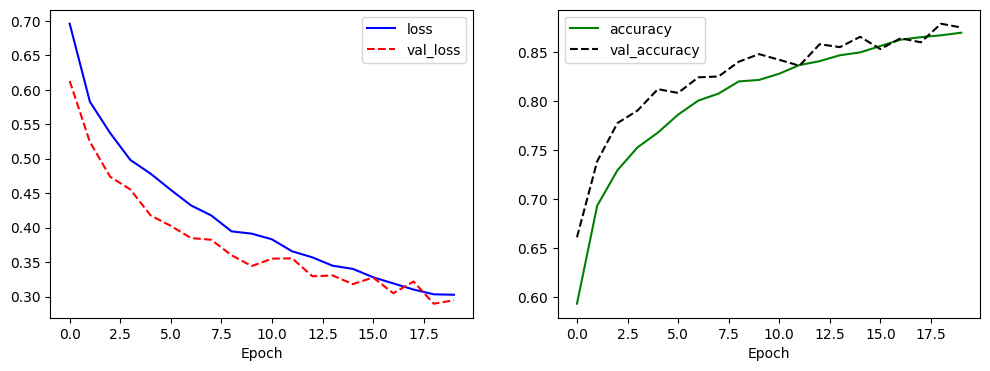

In [42]:
# 평가
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f"val_acc : {val_acc:.4f}, val_loss : {val_loss:.4f}")

# 학습곡선 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'g-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'k--', label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


Found 4653 images belonging to 2 classes.


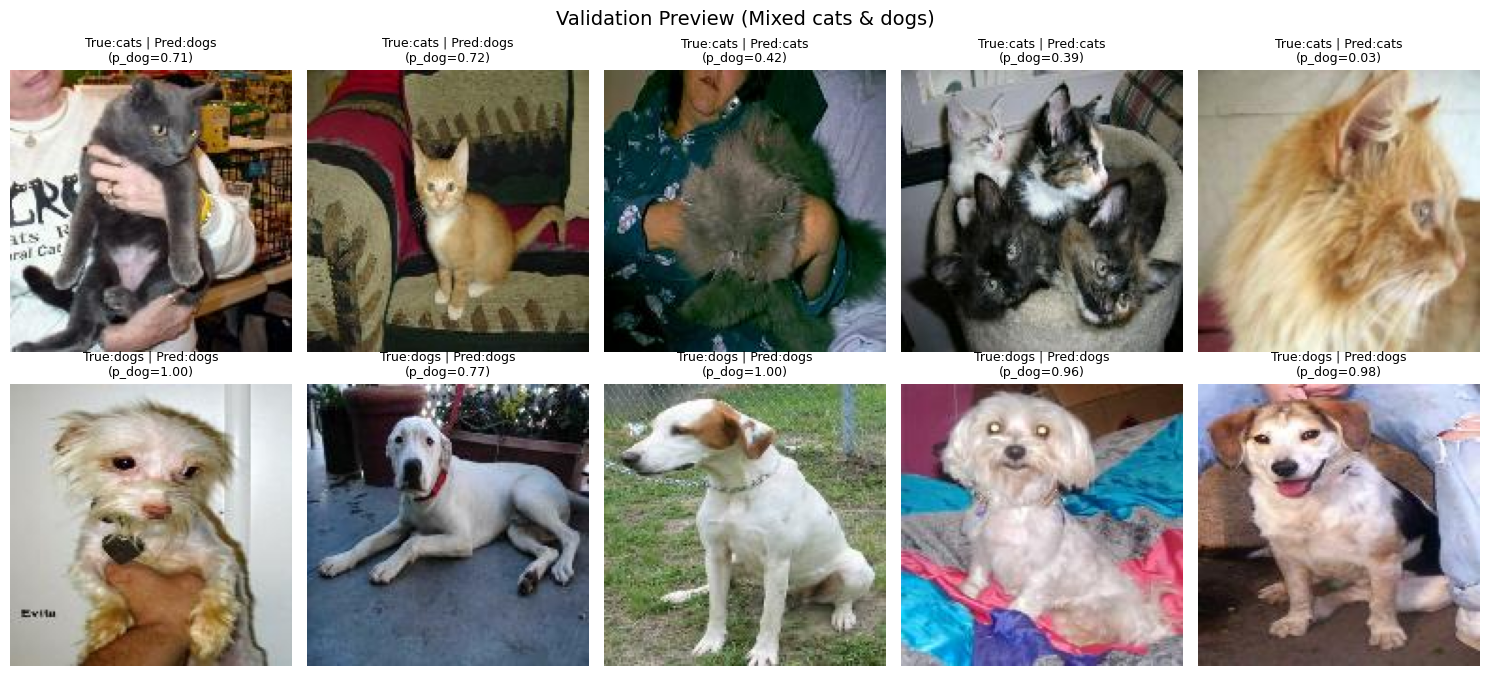

In [44]:
# 검증 배치 예측 확인
preview_gen = ImageDataGenerator(rescale = 1./255)
preview_flow = preview_gen.flow_from_directory(
    validation_dir,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 24,
    class_mode = 'binary',
    shuffle = True,
    seed = 123
)

# 예측용 개/고양이 보기(5개)
n_each = 5  # 개/고양이 각각 n개를 모을 때까지 여러 배치 이어받기

cats_images, dogs_images = [], []
while len(cats_images) < n_each or len(dogs_images) < n_each:
  imgs, labels = next(preview_flow)
  for im, ib in zip(imgs, labels):
    if ib == 0 and len(cats_images) < n_each:
      cats_images.append(im)
    elif ib == 1 and len(dogs_images) < n_each:
      dogs_images.append(im)
    if len(cats_images) >= n_each and len(dogs_images) >= n_each:
      break;

# 예측
cats_probs = model.predict(np.array(cats_images), verbose=0).ravel()
dogs_probs = model.predict(np.array(dogs_images), verbose=0).ravel()

# 에측 결과 시각화
rows, cols = 2, n_each
plt.figure(figsize=(15, 7))
for i in range(n_each):
  # cats rows
  ax1 = plt.subplot(rows, cols, i+1)
  ax1.imshow(cats_images[i])
  ax1.axis('off')
  p_cat = cats_probs[i]
  pred_label = 'dogs' if p_cat >= 0.5 else 'cats'
  ax1.set_title(f'True:cats | Pred:{pred_label}\n(p_dog={p_cat:.2f})', fontsize=9)

  # dogs rows
  ax2 = plt.subplot(rows, cols, cols + i+1)
  ax2.imshow(dogs_images[i])
  ax2.axis('off')
  p_dog = dogs_probs[i]
  pred_label = 'dogs' if p_dog >= 0.5 else 'cats'
  ax2.set_title(f'True:dogs | Pred:{pred_label}\n(p_dog={p_dog:.2f})', fontsize=9)

plt.suptitle('Validation Preview (Mixed cats & dogs)', fontsize=14)
plt.tight_layout()
plt.show()